# **California**

- Use different training window lengths (e.g., T_train = 90, 120, 150) for experiments.
- Use different parameter settings for each city.

In [3]:
import os
save_dir = #######
os.makedirs(save_dir, exist_ok=True)

/var/folders/7q/50zwnmhx4g518srg_9fb7kq80000gn/T/ipykernel_15496/3855008861.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")


Seasonal peak aligned near: 2021-01-10 00:00:00 => t0 index = 312

T_total=360, train_start=60, train_end=150, T_train=90
gamma=1.01, lam=0.0 (ridge OFF), ode_method=RK45
Constraint enforced: delta_RT1<0 and delta_SP1<0 via -softplus

=== Point estimate delta (Eq.11) (ridge OFF) ===
delta_hat = [delta_RT1, delta_RT0, delta_SP1, delta_SP0]
[-7.584100e-02  2.805628e+00 -2.630000e-04 -5.519660e-01]
Train RMSE (WLS residual) = 0.00013445889520005287


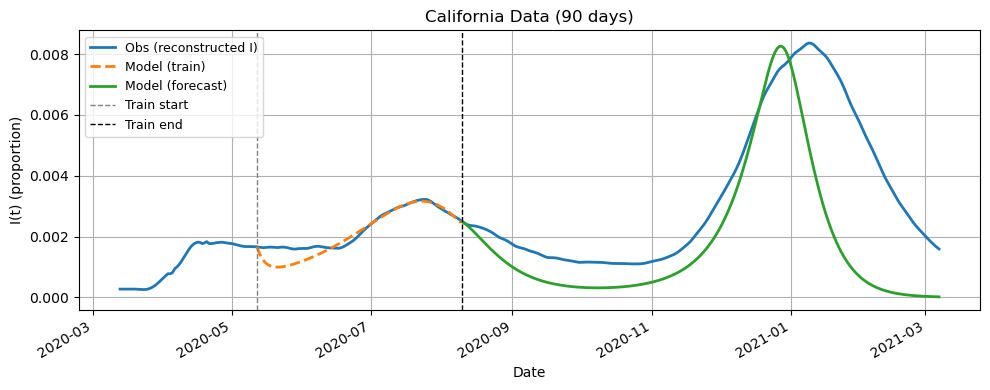

MC progress: 25/200 valid samples
MC progress: 50/200 valid samples
MC progress: 75/200 valid samples
MC progress: 100/200 valid samples
MC progress: 125/200 valid samples
MC progress: 150/200 valid samples
MC progress: 175/200 valid samples
MC progress: 200/200 valid samples

MC finished: 200/200 valid samples

=== delta summary across MC samples ===
Order: [delta_RT1, delta_RT0, delta_SP1, delta_SP0]
median: [-5.363900e-02  2.601267e+00 -3.000000e-06 -1.694610e-01]
2.5%  : [-0.365484 -0.892498 -0.056531 -3.042956]
97.5% : [-0.        4.773039 -0.        2.318878]

=== Behavioral regime (MC median, figure-based) ===
Regime : Q2-TOC
Slope0 = (R0-T0)/(S0-P0): -15.3503
Slope1 = (T1-R1)/(P1-S1): 17081.3586

=== Training LSE summary (delta Eq.11) ===
Median LSE : 2.151495214242085e-08
Mean LSE   : 2.260886548483752e-08


/Users/sghong/anaconda3/envs/research/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


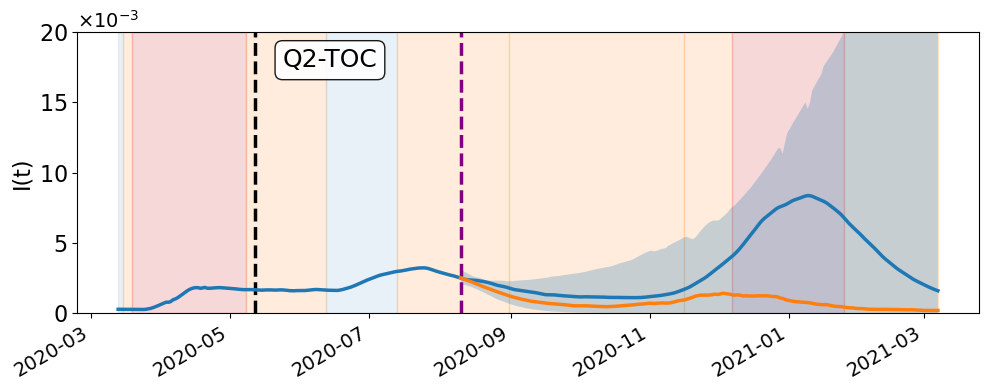

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.signal import savgol_filter

# =========================================================
# Arizona: Estimate payoff gaps (delta) directly via Eq.(10)
# + CONSTRAINT: delta_RT1 < 0 and delta_SP1 < 0 via reparameterization
#   delta_RT1 = -softplus(z_RT1), delta_SP1 = -softplus(z_SP1)
#
# Parameters optimized:
#   p = [z_RT1, delta_RT0, z_SP1, delta_SP0]
# Derived:
#   delta = [delta_RT1, delta_RT0, delta_SP1, delta_SP0]
#
# Keep same:
# - hospitalization->I reconstruction
# - seasonal beta0
# - obs-aligned forecast start
# - Monte Carlo CI (perturb disease params)
# =========================================================

# =========================
# 0) Load data (DATE sorting + daily reindex)
# =========================
H_COL = "hospitalizedCurrently"
DATE_COL = "date"
CSV_PATH = "california-history.csv"

df = pd.read_csv(CSV_PATH)

if DATE_COL not in df.columns:
    raise ValueError(f"Column '{DATE_COL}' not found. Available columns: {df.columns.tolist()}")
if H_COL not in df.columns:
    raise ValueError(f"Column '{H_COL}' not found. Available columns: {df.columns.tolist()}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL])
df = df.sort_values(DATE_COL).drop_duplicates(subset=[DATE_COL], keep="last").reset_index(drop=True)

# daily grid
df = df.set_index(DATE_COL).asfreq("D")
df[H_COL] = pd.to_numeric(df[H_COL], errors="coerce")
df[H_COL] = df[H_COL].interpolate(limit_direction="both").fillna(0.0)
df = df.reset_index()

h_raw = df[H_COL].to_numpy(dtype=float)
h_raw = np.nan_to_num(h_raw, nan=0.0)
dates = df[DATE_COL].to_numpy()  # datetime64 for plotting


# =========================
# 1) Hospitalization -> Infection (reconstructed I)
# =========================
def estimate_I_from_hospitalizations(
    h, kappa_hat, tau_hat,
    T=None,
    window_length=15, polyorder=3,
    clip_nonneg=True,
    dt=1.0
):
    h = np.asarray(h, dtype=float)
    if h.ndim != 1:
        raise ValueError("h must be a 1D array")
    if kappa_hat <= 0:
        raise ValueError("kappa_hat must be positive")
    if tau_hat < 0:
        raise ValueError("tau_hat must be nonnegative")

    n = len(h)
    tau_hat = int(round(tau_hat))
    max_T = (n - 1) - tau_hat
    if max_T < 0:
        raise ValueError("h is too short for given tau_hat")

    if T is None:
        T = max_T
    if T > max_T:
        raise ValueError(f"T too large. Max feasible T is {max_T}.")

    wl = int(window_length)
    if wl % 2 == 0:
        wl += 1
    wl = min(wl, n if n % 2 == 1 else n - 1)
    if wl < polyorder + 2:
        wl = polyorder + 2
        if wl % 2 == 0:
            wl += 1
        wl = min(wl, n if n % 2 == 1 else n - 1)

    h_s = savgol_filter(h, window_length=wl, polyorder=polyorder, mode="interp")
    if clip_nonneg:
        h_s = np.clip(h_s, 0.0, None)

    idx = np.arange(T + 1) + tau_hat
    I_hat = h_s[idx] / kappa_hat
    if clip_nonneg:
        I_hat = np.clip(I_hat, 0.0, None)

    dI_hat = (I_hat[1:] - I_hat[:-1]) / dt
    return I_hat, dI_hat, h_s


# =========================
# 2) SEIR + Replicator (seasonal beta0) + Eq.(10)
# =========================
def beta0_seasonal(t_abs, beta0_s, beta0_w, t0):
    return 0.5*(beta0_s + beta0_w) + 0.5*(beta0_w - beta0_s)*np.cos(2*np.pi*(t_abs - t0)/365.0)

def replicator_gap_eq11(x, theta, delta_vec):
    """
    Eq.(11) bracket term:
      gap(x,theta) =
        x*theta*delta_RT1 + x*(1-theta)*delta_RT0
      + (1-x)*theta*delta_SP1 + (1-x)*(1-theta)*delta_SP0
    """
    dRT1, dRT0, dSP1, dSP0 = delta_vec
    return (x*theta*dRT1
            + x*(1-theta)*dRT0
            + (1-x)*theta*dSP1
            + (1-x)*(1-theta)*dSP0)

def seir_replicator_ode_delta(y, t, pars, delta_vec, epsilon, beta0_s, beta0_w, t0, t_shift=0.0):
    S, E, I, R, x = y
    alpha, eta, mu = pars

    t_abs = t + t_shift
    beta0_t = beta0_seasonal(t_abs, beta0_s, beta0_w, t0)

    theta = np.clip(1 - epsilon*I, 0.0, 1.0)

    gap = replicator_gap_eq11(x, theta, delta_vec)
    dxdt = x*(1-x)*gap

    beta_t = beta0_t*(1-x)

    dSdt = -beta_t*S*I + mu*R
    dEdt =  beta_t*S*I - eta*E
    dIdt =  eta*E - alpha*I
    dRdt =  alpha*I - mu*R

    return np.array([dSdt, dEdt, dIdt, dRdt, dxdt])

def simulate_I_delta(time, y0, alpha, eta, mu, beta0_s, beta0_w, t0, epsilon, delta_vec, t_shift=0.0, method="RK45"):
    def ode_wrapper(t, y):
        return seir_replicator_ode_delta(
            y, t, (alpha, eta, mu),
            delta_vec, epsilon,
            beta0_s, beta0_w, t0,
            t_shift=t_shift
        )

    t_span = (float(time[0]), float(time[-1]))
    sol = solve_ivp(
        ode_wrapper,
        t_span,
        y0,
        method=method,
        t_eval=time,
        rtol=1e-6,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    I = sol.y[2, :]
    sol_mat = sol.y.T
    return I, sol_mat


# =========================
# 2.5) Align state at OBSERVED point
# =========================
def align_state_to_observation(y_ref, I_obs, idx, alpha, eta, dI_obs=None, mu=0.0, clip=1e-8):
    y = y_ref.copy()
    S, E, I, R, x = y

    I_new = float(I_obs[idx])
    I_new = max(I_new, clip)

    if dI_obs is not None:
        dI_new = float(dI_obs[idx]) if idx < len(dI_obs) else float(dI_obs[-1])
        E_new = (dI_new + alpha * I_new) / max(eta, clip)
        E_new = max(E_new, clip)
    else:
        E_new = max(E, clip)

    R_new = max(R, clip)
    S_new = 1.0 - (E_new + I_new + R_new)
    S_new = max(S_new, clip)

    return np.array([S_new, E_new, I_new, R_new, x], dtype=float)


# =========================
# 3) Constrained delta unpacking (δ_RT1<0, δ_SP1<0 via -softplus)
# =========================
def softplus(z):
    # numerically stable softplus
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0.0)

def unpack_delta_constrained(p):
    """
    p = [z_RT1, δ_RT0, z_SP1, δ_SP0]
    delta = [δ_RT1, δ_RT0, δ_SP1, δ_SP0]
    with constraints δ_RT1<0 and δ_SP1<0
    """
    z_RT1, dRT0, z_SP1, dSP0 = p
    dRT1 = -softplus(z_RT1)  # < 0
    dSP1 = -softplus(z_SP1)  # < 0
    return np.array([dRT1, dRT0, dSP1, dSP0], dtype=float)

def inv_softplus(y):
    # solve softplus(z)=y for y>0
    # z = log(exp(y)-1)
    y = max(float(y), 1e-12)
    return np.log(np.expm1(y))

#lam=0 -> NO ridge in this problem. 
#Users can increase lam to add regularization if they want.
def residuals_delta_only_ridge(
    p, time, y0, I_obs,
    alpha, eta, mu,
    beta0_s, beta0_w, t0,
    epsilon,
    t_shift=0.0,
    gamma=1.01,
    lam=0.0,
    ode_method="RK45"
):
    delta_hat = unpack_delta_constrained(p)

    I_model, _ = simulate_I_delta(
        time=time,
        y0=y0,
        alpha=alpha, eta=eta, mu=mu,
        beta0_s=beta0_s, beta0_w=beta0_w, t0=t0,
        epsilon=epsilon,
        delta_vec=delta_hat,
        t_shift=t_shift,
        method=ode_method
    )

    resid = I_model - I_obs
    T = len(resid)
    w = gamma ** (np.arange(T) - (T - 1))
    data_term = w * resid

    if lam is None or lam <= 0.0:
        return data_term

    ridge_term = np.sqrt(lam) * np.array(p, dtype=float)
    return np.concatenate([data_term, ridge_term])

def fit_delta_least_squares(
    time, y0, I_obs,
    alpha, eta, mu,
    beta0_s, beta0_w, t0,
    epsilon,
    t_shift=0.0,
    p0=None,
    gamma=1.01,
    lam=0.0,
    max_nfev=8000,
    ode_method="RK45",
    verbose=0
):
    # p = [z_RT1, δ_RT0, z_SP1, δ_SP0]
    if p0 is None:
        # target δ_RT1≈-0.2, δ_SP1≈-0.2
        z0 = inv_softplus(0.2)
        p0 = np.array([z0, 0.2, z0, 0.2], dtype=float)

    fun = lambda p: residuals_delta_only_ridge(
        p, time, y0, I_obs,
        alpha, eta, mu,
        beta0_s, beta0_w, t0,
        epsilon,
        t_shift=t_shift,
        gamma=gamma,
        lam=lam,
        ode_method=ode_method
    )

    res = least_squares(fun, p0, method="trf", max_nfev=max_nfev, verbose=verbose)
    delta_hat = unpack_delta_constrained(res.x)
    return res, delta_hat, res.x  # return also unconstrained p if you want


# =========================
# 4) Sampling utilities (±rel_std Gaussian noise)
# =========================
def sample_pos_gauss_clip(mean, rel_std=0.05, clip_sigma=2, minval=1e-8):
    std = rel_std * mean
    low = mean - clip_sigma * std
    high = mean + clip_sigma * std
    x = np.random.normal(mean, std)
    x = np.clip(x, low, high)
    return max(x, minval)

def sample_tau_int_clip(mean, rel_std=0.05, clip_sigma=2, min_tau=0, max_tau=60):
    std = rel_std * mean
    low = mean - clip_sigma * std
    high = mean + clip_sigma * std
    x = np.random.normal(mean, std)
    x = int(np.round(x))
    x = int(np.clip(x, low, high))
    return int(np.clip(x, min_tau, max_tau))


# =========================
# 5) SETTINGS (edit here)
# =========================
kappa_hat = 0.07
tau_hat   = 9

alpha = 0.15
eta   = 0.11
mu    = 0.0

beta0_s = 0.35
beta0_w = 0.55

epsilon = 20.0

train_start = 60
T_train     = 90
train_end   = train_start + T_train

sg_window = 15
sg_poly   = 3

N_pop = 39_000_000

gamma = 1.01
lam = 0.0
ode_method = "RK45"

N_MC = 200
rel_std = 0.1
clip_sigma = 2
seed = 0
if seed is not None:
    np.random.seed(seed)



# =========================
# 6) Seasonal peak alignment (t0)
# =========================
winter_peak_month = 1
winter_peak_day   = 10
year0 = df[DATE_COL].dt.year.iloc[0]
target_date = pd.Timestamp(year0, winter_peak_month, winter_peak_day)
if target_date < df[DATE_COL].min():
    target_date = pd.Timestamp(year0 + 1, winter_peak_month, winter_peak_day)
t0 = int((df[DATE_COL] - target_date).abs().idxmin())
print("Seasonal peak aligned near:", df.loc[t0, DATE_COL], "=> t0 index =", t0)


# =========================
# 7) BASELINE: Build I_obs, fit delta, simulate training + forecast (OBS-aligned start)
# =========================
I_obs_full_count, dI_hat_full_count, h_smooth = estimate_I_from_hospitalizations(
    h=h_raw,
    kappa_hat=kappa_hat,
    tau_hat=tau_hat,
    T=None,
    window_length=sg_window,
    polyorder=sg_poly,
    clip_nonneg=True
)

I_obs_full = I_obs_full_count / N_pop
T_total = len(I_obs_full)

dI_hat_full = np.concatenate([dI_hat_full_count, [dI_hat_full_count[-1]]]) / N_pop
t_full = np.arange(T_total)

tau_int = int(round(tau_hat))
dates_I = dates[tau_int: tau_int + T_total]

if train_end > T_total:
    raise ValueError("Training window exceeds available data length.")

print(f"\nT_total={T_total}, train_start={train_start}, train_end={train_end}, T_train={T_train}")
print(f"gamma={gamma}, lam={lam} (ridge OFF), ode_method={ode_method}")
print("Constraint enforced: delta_RT1<0 and delta_SP1<0 via -softplus")

# initial state at train_start
I0 = float(I_obs_full[train_start])
E0 = 1e-4
R0 = 1e-4
x0 = 0.5
S0 = max(1.0 - (E0 + I0 + R0), 1e-6)
y_start = np.array([S0, E0, I0, R0, x0])

# training data
train_idx = np.arange(train_start, train_end)
t_train = t_full[train_idx]
t_train_rel = t_train - t_train[0]
I_obs_train = I_obs_full[train_idx]

# fit delta
res0, delta_hat0, p_hat0 = fit_delta_least_squares(
    time=t_train_rel,
    y0=y_start,
    I_obs=I_obs_train,
    alpha=alpha, eta=eta, mu=mu,
    beta0_s=beta0_s, beta0_w=beta0_w, t0=t0,
    epsilon=epsilon,
    t_shift=float(train_start),
    p0=None,
    gamma=gamma,
    lam=lam,
    max_nfev=8000,
    ode_method=ode_method,
    verbose=0
)

# simulate through train to get terminal training state y_end0
t_fit = np.arange(0, T_train + 1)
I_fit0, sol_fit0 = simulate_I_delta(
    time=t_fit,
    y0=y_start,
    alpha=alpha, eta=eta, mu=mu,
    beta0_s=beta0_s, beta0_w=beta0_w, t0=t0,
    epsilon=epsilon,
    delta_vec=delta_hat0,
    t_shift=float(train_start),
    method=ode_method
)
y_end0 = sol_fit0[-1, :]

# align forecast start at OBS point (train_end)
y_obs0 = align_state_to_observation(
    y_ref=y_end0,
    I_obs=I_obs_full,
    idx=train_end,
    alpha=alpha,
    eta=eta,
    dI_obs=dI_hat_full,
    mu=mu
)

# forecast after train_end
t_fore = np.arange(0, T_total - train_end)
I_fore0, _ = simulate_I_delta(
    time=t_fore,
    y0=y_obs0,
    alpha=alpha, eta=eta, mu=mu,
    beta0_s=beta0_s, beta0_w=beta0_w, t0=t0,
    epsilon=epsilon,
    delta_vec=delta_hat0,
    t_shift=float(train_end),
    method=ode_method
)

I_point = np.full(T_total, np.nan)
I_point[train_start:train_end+1] = I_fit0
I_point[train_end:] = I_fore0

print("\n=== Point estimate delta (Eq.11) (ridge OFF) ===")
print("delta_hat = [delta_RT1, delta_RT0, delta_SP1, delta_SP0]")
print(np.round(delta_hat0, 6))
print("Train RMSE (WLS residual) =", np.sqrt(np.mean(res0.fun**2)))

plt.figure(figsize=(10, 4))
plt.plot(dates_I, I_obs_full, lw=2, label="Obs (reconstructed I)")
plt.plot(dates_I[train_start:train_end+1],
         I_point[train_start:train_end+1],
         lw=2, ls="--", label="Model (train)")
plt.plot(dates_I[train_end:],
         I_point[train_end:],
         lw=2, ls="-", label="Model (forecast)")
plt.axvline(dates_I[train_start], ls="--", lw=1, color="gray", label="Train start")
plt.axvline(dates_I[train_end],   ls="--", lw=1, color="black", label="Train end")
plt.title("California Data (90 days)")
plt.xlabel("Date")
plt.ylabel("I(t) (proportion)")
plt.grid(True)
plt.legend(fontsize=9)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


# =========================
# 8) MONTE CARLO 95% CI (±rel_std Gaussian noise on disease params)
# =========================
LSE_mc    = np.full(N_MC, np.nan)
I_mc      = np.full((N_MC, T_total), np.nan)
DELTA_mc  = np.full((N_MC, 4), np.nan)

valid = 0
max_tries = N_MC * 3

for k in range(max_tries):
    if valid >= N_MC:
        break

    alpha_s = sample_pos_gauss_clip(alpha, rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)
    eta_s   = sample_pos_gauss_clip(eta,   rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)
    kappa_s = sample_pos_gauss_clip(kappa_hat, rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)
    tau_s   = sample_tau_int_clip(tau_hat, rel_std=rel_std, clip_sigma=clip_sigma, min_tau=0, max_tau=60)
    beta0_s_s = sample_pos_gauss_clip(beta0_s, rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)
    beta0_w_s = sample_pos_gauss_clip(beta0_w, rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)

    try:
        I_s_count, dI_s_count, _ = estimate_I_from_hospitalizations(
            h=h_raw,
            kappa_hat=kappa_s,
            tau_hat=tau_s,
            T=None,
            window_length=sg_window,
            polyorder=sg_poly,
            clip_nonneg=True
        )
        I_s = I_s_count / N_pop
        if len(I_s) != T_total:
            continue

        dI_s = np.concatenate([dI_s_count, [dI_s_count[-1]]]) / N_pop

        I0_s = float(I_s[train_start])
        E0_s = 1e-4
        R0_s = 1e-4
        x0_s = 0.5
        S0_s = max(1.0 - (E0_s + I0_s + R0_s), 1e-6)
        y_start_s = np.array([S0_s, E0_s, I0_s, R0_s, x0_s])

        I_train_s = I_s[train_idx]

        res_s, delta_hat_s, _ = fit_delta_least_squares(
            time=t_train_rel,
            y0=y_start_s,
            I_obs=I_train_s,
            alpha=alpha_s, eta=eta_s, mu=mu,
            beta0_s=beta0_s_s, beta0_w=beta0_w_s, t0=t0,
            epsilon=epsilon,
            t_shift=float(train_start),
            p0=None,
            gamma=gamma,
            lam=0.0,
            max_nfev=6000,
            ode_method=ode_method,
            verbose=0
        )

        lse_s = np.mean(res_s.fun**2)
        LSE_mc[valid] = lse_s

        I_fit_s, sol_fit_s = simulate_I_delta(
            time=t_fit,
            y0=y_start_s,
            alpha=alpha_s, eta=eta_s, mu=mu,
            beta0_s=beta0_s_s, beta0_w=beta0_w_s, t0=t0,
            epsilon=epsilon,
            delta_vec=delta_hat_s,
            t_shift=float(train_start),
            method=ode_method
        )
        y_end_s = sol_fit_s[-1, :]

        y_obs_s = align_state_to_observation(
            y_ref=y_end_s,
            I_obs=I_s,
            idx=train_end,
            alpha=alpha_s,
            eta=eta_s,
            dI_obs=dI_s,
            mu=mu
        )

        I_fore_s, _ = simulate_I_delta(
            time=t_fore,
            y0=y_obs_s,
            alpha=alpha_s, eta=eta_s, mu=mu,
            beta0_s=beta0_s_s, beta0_w=beta0_w_s, t0=t0,
            epsilon=epsilon,
            delta_vec=delta_hat_s,
            t_shift=float(train_end),
            method=ode_method
        )

        I_full_s = np.full(T_total, np.nan)
        I_full_s[train_start:train_end+1] = I_fit_s
        I_full_s[train_end:] = I_fore_s

        I_mc[valid, :] = I_full_s
        DELTA_mc[valid, :] = delta_hat_s
        valid += 1

        if valid % 25 == 0:
            print(f"MC progress: {valid}/{N_MC} valid samples")

    except Exception:
        continue

if valid < max(20, N_MC//4):
    print(f"\nWARNING: only {valid} valid MC samples out of requested {N_MC}.")
    print("Try: ode_method='Radau', reduce epsilon, or reduce rel_std.")
else:
    print(f"\nMC finished: {valid}/{N_MC} valid samples")

DELTA_valid = DELTA_mc[:valid, :]
delta_median = np.nanpercentile(DELTA_valid, 50.0, axis=0)
delta_lower  = np.nanpercentile(DELTA_valid, 2.5, axis=0)
delta_upper  = np.nanpercentile(DELTA_valid, 97.5, axis=0)

print("\n=== delta summary across MC samples ===")
print("Order: [delta_RT1, delta_RT0, delta_SP1, delta_SP0]")
print("median:", np.round(delta_median, 6))
print("2.5%  :", np.round(delta_lower, 6))
print("97.5% :", np.round(delta_upper, 6))

# =========================
# 8.5) Quadrant + Q1 high/low 
# =========================
δ_RT1, δ_RT0, δ_SP1, δ_SP0 = delta_median
eps = 1e-10

# Quadrants (figure-based)
if δ_RT0 > 0 and δ_SP0 > 0:
    quad = "Q1"
elif δ_RT0 > 0 and δ_SP0 < 0:
    quad = "Q2-TOC"
elif δ_RT0 < 0 and δ_SP0 < 0:
    quad = "Q3-TOC"
else:
    quad = "Q4-Diminishing Oscillations"

# Q1 high/low rule:
# slope0 = (R0-T0)/(S0-P0) = δ_RT0 / δ_SP0
# slope1 = (T1-R1)/(P1-S1) = (-δ_RT1)/(-δ_SP1)
if abs(δ_SP0) > eps:
    slope0 = δ_RT0 / δ_SP0
else:
    slope0 = np.nan
if abs(δ_SP1) > eps:
    slope1 = (-δ_RT1) / (-δ_SP1)
else:
    slope1 = np.nan

if quad == "Q1":
    if np.isnan(slope0) or np.isnan(slope1):
        quad_full = "Q1-undefined"
    elif slope0 > slope1:
        quad_full = "Q1-Oscillating TOC"
    else:
        quad_full = "Q1-Diminishing Oscillations"
else:
    quad_full = quad

print("\n=== Behavioral regime (MC median, figure-based) ===")
print("Regime :", quad_full)
print("Slope0 = (R0-T0)/(S0-P0):", np.round(slope0, 4))
print("Slope1 = (T1-R1)/(P1-S1):", np.round(slope1, 4))

LSE_valid = LSE_mc[:valid]
print("\n=== Training LSE summary (delta Eq.11) ===")
print("Median LSE :", np.median(LSE_valid))
print("Mean LSE   :", np.mean(LSE_valid))


from datetime import datetime
from matplotlib.patches import Patch
from datetime import datetime

## California mandate levels (3-level, continuous periods; simplified statewide)

# Notes:
# - Starting from August 31, 2020, policies followed the Blueprint (Tier) system at the county level. For simplicity, we use a statewide approximation:
#   (periods where most counties remained in Purple/Tier 1 are treated as Level 2) / (periods with clear stay-at-home characteristics are treated as Level 3).
# - End dates are defined as exclusive (i.e., up to but not including the specified date) to align with Python slicing conventions.


mandate_periods_CA = [
    (datetime(2020, 3, 4),  datetime(2020, 3, 15), 1, "State of Emergency declared (response posture)"),  
    (datetime(2020, 3, 15), datetime(2020, 3, 19), 2, "Targeted closures (bars/wineries/nightclubs etc.)"),
    (datetime(2020, 3, 19), datetime(2020, 5, 8),  3, "Statewide stay-at-home (EO N-33-20)"),
    (datetime(2020, 5, 8),  datetime(2020, 6, 12), 2, "Stage 2 transition + sector guidance (partial reopening)"),
    (datetime(2020, 6, 12), datetime(2020, 7, 13), 1, "Broader reopening (modified operations)"),
    (datetime(2020, 7, 13), datetime(2020, 8, 31), 2, "Statewide indoor rollbacks + county watchlist closures"),
    (datetime(2020, 8, 31), datetime(2020, 11, 16), 2, "Blueprint tier system (county-level; statewide simplified high restriction)"),
    (datetime(2020, 11, 16), datetime(2020, 12, 7),  2, "Re-tightening as cases surge (Blueprint largely shelved)"),
    (datetime(2020, 12, 7),  datetime(2021, 1, 25), 3, "Regional Stay-at-Home Order era"),
    (datetime(2021, 1, 25), datetime(2021, 4, 15), 2, "Post-regional-order tier restrictions (improving but still tight)"),
    (datetime(2021, 4, 15), datetime(2030, 1, 1),  1, "Reopening easing (expanded gatherings/events under tier rules)"),
]




level_style = {
    3: {"color": "#d62728", "alpha": 0.18, "label": "Level 3 (strong suppression)"},
    2: {"color": "#ff7f0e", "alpha": 0.14, "label": "Level 2 (mitigation)"},
    1: {"color": "#1f77b4", "alpha": 0.10, "label": "Level 1 (relaxed mitigation)"},
}

def shade_mandates(ax, periods, x_min=None, x_max=None):
    for (s, e, lvl, txt) in periods:   
        if x_min is not None and e <= x_min:
            continue
        if x_max is not None and s >= x_max:
            continue

        ss = max(s, x_min) if x_min is not None else s
        ee = min(e, x_max) if x_max is not None else e

        if ss < ee:
            ax.axvspan(
                ss, ee,
                color=level_style[lvl]["color"],
                alpha=level_style[lvl]["alpha"],
                zorder=0
            )

    # legend patches (unique by level)
    patches = []
    seen = set()
    for (_, _, lvl, _) in periods:    
        if lvl not in seen:
            seen.add(lvl)
            patches.append(
                Patch(
                    facecolor=level_style[lvl]["color"],
                    alpha=level_style[lvl]["alpha"],
                    label=level_style[lvl]["label"]
                )
            )
    return patches

# =========================
# 9) 95% band plot + mandate shading (FULL timeline)
# =========================
# =========================
# (C) 95% band plot (NO title, NO grid, 10^-3 y-axis)
# =========================
I_mc_valid = I_mc[:valid, :]

I_lower  = np.nanpercentile(I_mc_valid,  2.5, axis=0)
I_median = np.nanpercentile(I_mc_valid, 50.0, axis=0)
I_upper  = np.nanpercentile(I_mc_valid, 97.5, axis=0)

x_all = pd.to_datetime(dates_I).to_pydatetime()

x_f  = x_all[train_end:]
lo_f = I_lower[train_end:]
md_f = I_median[train_end:]
up_f = I_upper[train_end:]

L = min(len(x_f), len(lo_f), len(md_f), len(up_f))
x_f  = x_f[:L]
lo_f = lo_f[:L]
md_f = md_f[:L]
up_f = up_f[:L]

plt.figure(figsize=(10, 4))
ax = plt.gca()

# ---- FULL WINDOW mandate shading ----
patches = shade_mandates(ax, mandate_periods_CA, x_min=x_all[0], x_max=x_all[-1])

# ---- Curves ----
ax.plot(x_all, I_obs_full, lw=2.5, label="Obs (reconstructed I)", zorder=3)
ax.fill_between(x_f, lo_f, up_f, alpha=0.25, label="95% CI (forecast)", zorder=2)
ax.plot(x_f, md_f, lw=2.5, label="Median (MC, forecast)", zorder=4)


)
# ---- Train start / end  ----
ax.axvline(
    x_all[train_start],
    ls="--",
    lw=2.5,
    color="black",
    label="Train start"
)

ax.axvline(
    x_all[train_end],
    ls="--",
    lw=2.5,
    color="purple",
    label="Train end"
)
x_text = x_all[train_start + int(0.2*(train_start))]
y_text = 0.018

ax.text(
    x_text, y_text,
    f"{quad_full}",
    fontsize=18,
    ha="left", va="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9),
    zorder=10
)

# ---- Legend ----
handles, labels = ax.get_legend_handles_labels()
handles = handles + patches
labels  = labels  + [p.get_label() for p in patches]


# ---- Labels ----
ax.set_ylabel("I(t)", fontsize=16)

# ---- GRID ----
ax.grid(False)

from matplotlib.ticker import FuncFormatter
# ---- y-axis scientific notation: ----
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, -3), useMathText=True)

# make the offset text (×10^-3) larger
ax.yaxis.get_offset_text().set_size(14)
# tick label size
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
# ---- x-axis formatting ----
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()

# ---- Legend: ----
handles, labels = ax.get_legend_handles_labels()
handles = handles + patches
labels  = labels  + [p.get_label() for p in patches]
#ax.legend(handles, labels, fontsize=13, loc="upper left", frameon=True)
ax.set_ylim(0, 0.02)
plt.tight_layout()
plt.savefig(f"{save_dir}/CA_90_20_CI.png", dpi=300, bbox_inches="tight")
plt.show()